# Touch Options: Interactive Analysis & Visualizations

**Product Type:** Path-Dependent Binary/Digital Option  
**Key Feature:** Binary payout based on whether barrier is touched or not

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Payoff Diagrams](#2-payoff-diagrams)
3. [Price Surfaces](#3-price-surfaces)
4. [Greeks Analysis](#4-greeks-analysis)
5. [Touch-NoTouch Parity](#5-touch-notouch-parity)
6. [Touch Probability Analysis](#6-touch-probability-analysis)
7. [Monte Carlo Analysis](#7-monte-carlo-analysis)
8. [Sample Paths Visualization](#8-sample-paths-visualization)

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# Color scheme
COLORS = {
    'one_touch': '#2ecc71',    # Green
    'no_touch': '#e74c3c',     # Red
    'touched': '#2ecc71',      # Green
    'not_touched': '#e74c3c',  # Red
    'barrier': '#9b59b6',      # Purple
    'path': '#3498db',         # Blue
    'payout': '#f39c12',       # Orange
}

In [2]:
# Base parameters for analysis
BASE_PARAMS = {
    'S0': 100.0,           # Initial spot price
    'T': 1.0,              # Time to maturity (1 year)
    'r': 0.05,             # Domestic risk-free rate (5%)
    'q': 0.02,             # Foreign rate / dividend yield (2%)
    'sigma': 0.20,         # Volatility (20%)
    'barrier_up': 115.0,   # Up barrier
    'barrier_down': 85.0,  # Down barrier
    'payout': 1.0,         # Payout amount (normalized)
}

# save figures
SAVE_FIGURES = False

print("Base Parameters:")
print("-" * 40)
for key, value in BASE_PARAMS.items():
    print(f"{key:15s}: {value}")

Base Parameters:
----------------------------------------
S0             : 100.0
T              : 1.0
r              : 0.05
q              : 0.02
sigma          : 0.2
barrier_up     : 115.0
barrier_down   : 85.0
payout         : 1.0


## Pricing Functions

In [3]:
def touch_mc_price(S0, T, r, q, sigma, barrier, direction='up',
                   touch_style='one_touch', payout=1.0,
                   n_paths=100000, n_steps=252, seed=42):
    """
    Monte Carlo pricer for touch options.
    
    Parameters
    ----------
    direction : str
        'up' (barrier above spot) or 'down' (barrier below spot)
    touch_style : str
        'one_touch' (pays if touched) or 'no_touch' (pays if NOT touched)
    
    Returns
    -------
    tuple : (price, std_error, paths, touched)
    """
    np.random.seed(seed)
    
    if T <= 0:
        # Check if already touched
        if direction == 'up':
            touched_now = S0 >= barrier
        else:
            touched_now = S0 <= barrier
        
        if touch_style == 'one_touch':
            return (payout if touched_now else 0.0), 0.0, None, None
        else:
            return (0.0 if touched_now else payout), 0.0, None, None
    
    dt = T / n_steps
    drift = (r - q - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Generate paths using antithetic variates
    Z = np.random.standard_normal((n_paths // 2, n_steps))
    Z = np.vstack([Z, -Z])  # Antithetic
    
    log_returns = drift + diffusion * Z
    log_paths = np.cumsum(log_returns, axis=1)
    
    # Include S0 in paths
    paths = np.column_stack([np.zeros(n_paths), log_paths])
    paths = S0 * np.exp(paths)
    
    # Check touch status
    if direction == 'up':
        max_spots = np.max(paths, axis=1)
        touched = max_spots >= barrier
    else:  # down
        min_spots = np.min(paths, axis=1)
        touched = min_spots <= barrier
    
    # Compute payoffs
    if touch_style == 'one_touch':
        payoffs = np.where(touched, payout, 0.0)
    else:  # no_touch
        payoffs = np.where(~touched, payout, 0.0)
    
    # Discount
    discounted = np.exp(-r * T) * payoffs
    price = np.mean(discounted)
    std_error = np.std(discounted) / np.sqrt(n_paths)
    
    return price, std_error, paths, touched


def touch_analytic_price(S0, T, r, q, sigma, barrier, direction='up',
                         touch_style='one_touch', payout=1.0):
    """
    Analytic price for touch options (continuous monitoring).
    """
    if T <= 0:
        if direction == 'up':
            touched = S0 >= barrier
        else:
            touched = S0 <= barrier
        if touch_style == 'one_touch':
            return payout if touched else 0.0
        return 0.0 if touched else payout
    
    # Already at or beyond barrier
    if direction == 'up' and S0 >= barrier:
        touch_prob = 1.0
    elif direction == 'down' and S0 <= barrier:
        touch_prob = 1.0
    else:
        mu = r - q - 0.5 * sigma**2
        lambda_ = mu / sigma**2
        sqrt_T = np.sqrt(T)
        
        if direction == 'up':
            a = np.log(barrier / S0)
        else:
            a = np.log(S0 / barrier)  # Note: different sign for down
        
        d1 = (a - mu * T) / (sigma * sqrt_T)
        d2 = (-a - mu * T) / (sigma * sqrt_T)
        
        if direction == 'up':
            touch_prob = norm.cdf(-d1) + (barrier / S0)**(2 * lambda_) * norm.cdf(d2)
        else:
            d1 = (-a + mu * T) / (sigma * sqrt_T)
            d2 = (-a - mu * T) / (sigma * sqrt_T)
            touch_prob = norm.cdf(d1) + (barrier / S0)**(2 * lambda_) * norm.cdf(-d2)
    
    if touch_style == 'one_touch':
        return payout * np.exp(-r * T) * touch_prob
    else:  # no_touch
        return payout * np.exp(-r * T) * (1 - touch_prob)

## 2. Payoff Diagrams

Visualizing the binary payoff structure for touch options.

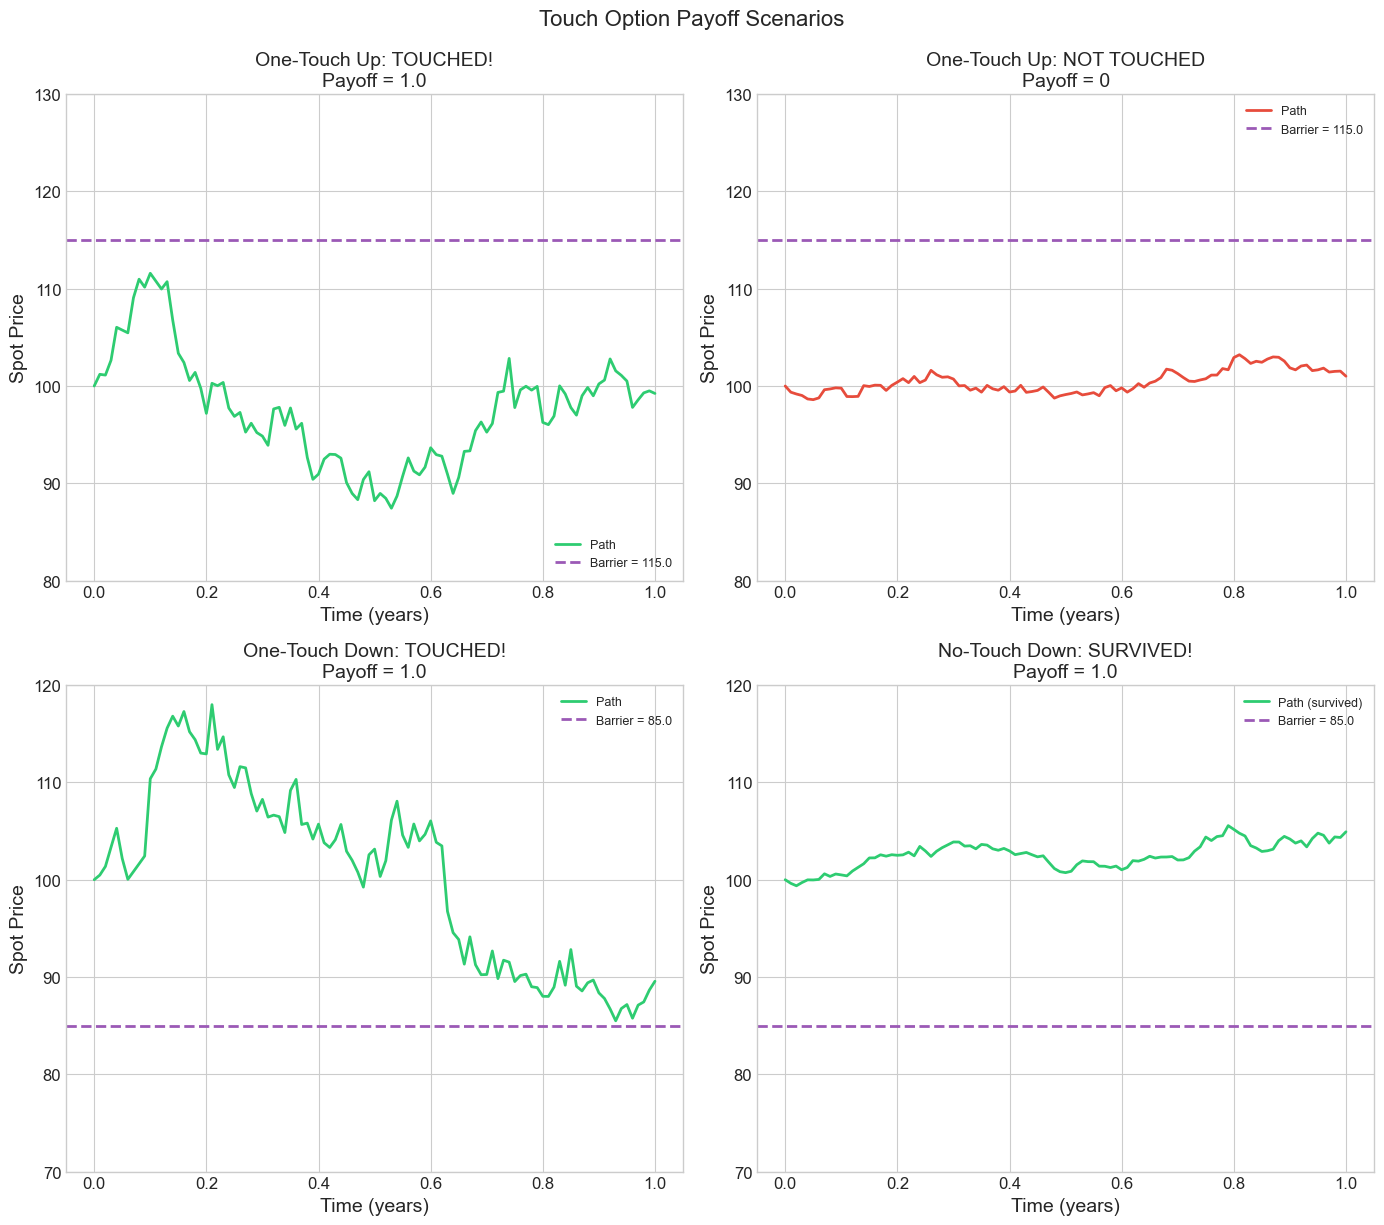

In [4]:
# Generate sample paths to illustrate payoffs
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

S0 = BASE_PARAMS['S0']
H_up = BASE_PARAMS['barrier_up']
H_down = BASE_PARAMS['barrier_down']
Q = BASE_PARAMS['payout']

# Generate example paths
np.random.seed(42)
n_steps = 100
dt = 1.0 / n_steps
t = np.linspace(0, 1, n_steps + 1)

# Path that touches up barrier
Z_touch_up = np.random.randn(n_steps) + 0.1
path_touch_up = S0 * np.exp(np.cumsum(np.insert(Z_touch_up * np.sqrt(dt) * 0.2, 0, 0)))

# Path that doesn't touch up barrier
Z_no_touch_up = np.random.randn(n_steps) * 0.3
path_no_touch_up = S0 * np.exp(np.cumsum(np.insert(Z_no_touch_up * np.sqrt(dt) * 0.15, 0, 0)))

# Path that touches down barrier
Z_touch_down = np.random.randn(n_steps) - 0.12
path_touch_down = S0 * np.exp(np.cumsum(np.insert(Z_touch_down * np.sqrt(dt) * 0.2, 0, 0)))

# Path that doesn't touch down barrier
Z_no_touch_down = np.random.randn(n_steps) * 0.3
path_no_touch_down = S0 * np.exp(np.cumsum(np.insert(Z_no_touch_down * np.sqrt(dt) * 0.15, 0, 0)))

# Ax 0: One-Touch Up - Touched
ax = axes[0, 0]
ax.plot(t, path_touch_up, color=COLORS['touched'], linewidth=2, label='Path')
ax.axhline(y=H_up, color=COLORS['barrier'], linestyle='--', linewidth=2, label=f'Barrier = {H_up}')
hit_idx = np.where(path_touch_up >= H_up)[0]
if len(hit_idx) > 0:
    ax.scatter([t[hit_idx[0]]], [path_touch_up[hit_idx[0]]], s=150, c='black', marker='x', zorder=5, label='Touch!')
ax.set_title(f'One-Touch Up: TOUCHED!\nPayoff = {Q}', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim([80, 130])

# Ax 1: One-Touch Up - Not Touched
ax = axes[0, 1]
ax.plot(t, path_no_touch_up, color=COLORS['not_touched'], linewidth=2, label='Path')
ax.axhline(y=H_up, color=COLORS['barrier'], linestyle='--', linewidth=2, label=f'Barrier = {H_up}')
ax.set_title(f'One-Touch Up: NOT TOUCHED\nPayoff = 0', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([80, 130])

# Ax 2: One-Touch Down - Touched
ax = axes[1, 0]
ax.plot(t, path_touch_down, color=COLORS['touched'], linewidth=2, label='Path')
ax.axhline(y=H_down, color=COLORS['barrier'], linestyle='--', linewidth=2, label=f'Barrier = {H_down}')
hit_idx = np.where(path_touch_down <= H_down)[0]
if len(hit_idx) > 0:
    ax.scatter([t[hit_idx[0]]], [path_touch_down[hit_idx[0]]], s=150, c='black', marker='x', zorder=5, label='Touch!')
ax.set_title(f'One-Touch Down: TOUCHED!\nPayoff = {Q}', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([70, 120])

# Ax 3: No-Touch Down - Not Touched
ax = axes[1, 1]
ax.plot(t, path_no_touch_down, color=COLORS['one_touch'], linewidth=2, label='Path (survived)')
ax.axhline(y=H_down, color=COLORS['barrier'], linestyle='--', linewidth=2, label=f'Barrier = {H_down}')
ax.set_title(f'No-Touch Down: SURVIVED!\nPayoff = {Q}', fontsize=14)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([70, 120])

plt.tight_layout()
plt.suptitle('Touch Option Payoff Scenarios', fontsize=16, y=1.02)
plt.show()

## 3. Price Surfaces

Visualizing how touch option prices vary with spot and volatility.

In [5]:
# Generate price surfaces for One-Touch Up
spots = np.linspace(90, 112, 20)
vols = np.linspace(0.10, 0.40, 20)
S_grid, vol_grid = np.meshgrid(spots, vols)

# Calculate prices
one_touch_up_prices = np.zeros_like(S_grid)
no_touch_up_prices = np.zeros_like(S_grid)

print("Computing price surfaces (this may take a moment)...")
for i in range(len(vols)):
    for j in range(len(spots)):
        S = spots[j]
        sigma = vols[i]
        
        one_touch_up_prices[i, j], _, _, _ = touch_mc_price(
            S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], sigma,
            BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch',
            n_paths=10000, n_steps=100
        )
        no_touch_up_prices[i, j], _, _, _ = touch_mc_price(
            S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], sigma,
            BASE_PARAMS['barrier_up'], direction='up', touch_style='no_touch',
            n_paths=10000, n_steps=100
        )

print("Done!")

Computing price surfaces (this may take a moment)...
Done!


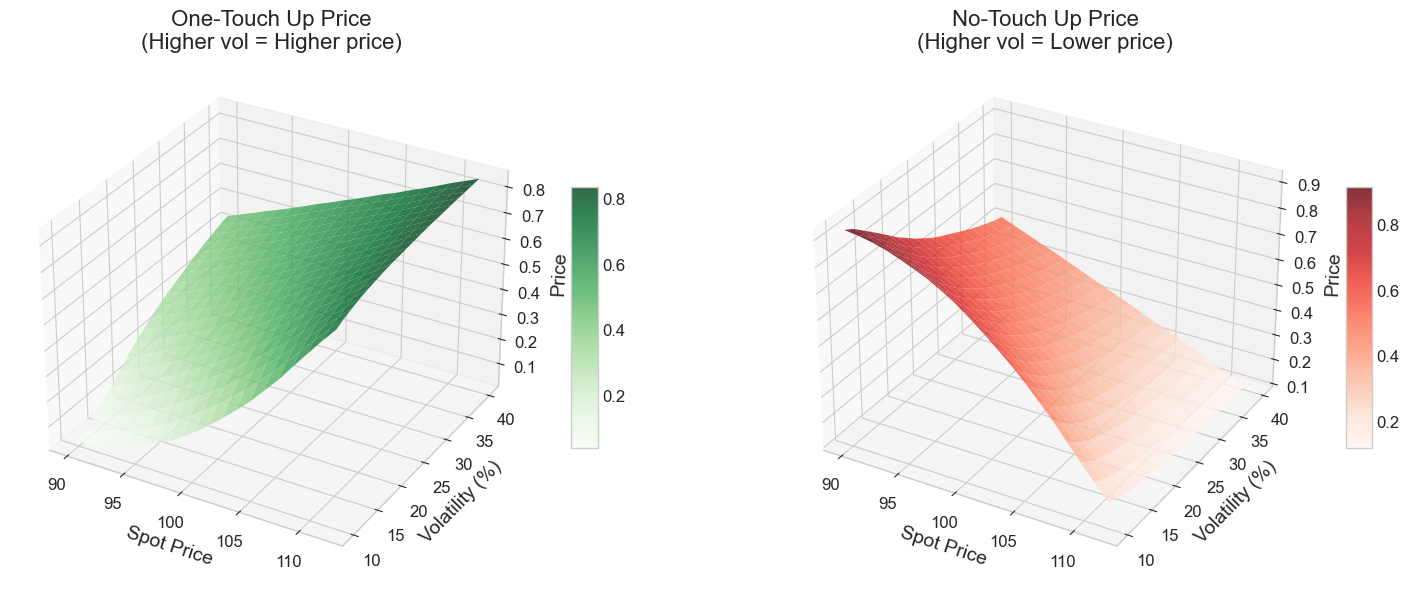

In [6]:
# Plot 3D surfaces
fig = plt.figure(figsize=(16, 6))

# One-Touch Up surface
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, vol_grid * 100, one_touch_up_prices, cmap=cm.Greens, alpha=0.8)
ax1.set_xlabel('Spot Price')
ax1.set_ylabel('Volatility (%)')
ax1.set_zlabel('Price')
ax1.set_title('One-Touch Up Price\n(Higher vol = Higher price)')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# No-Touch Up surface
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, vol_grid * 100, no_touch_up_prices, cmap=cm.Reds, alpha=0.8)
ax2.set_xlabel('Spot Price')
ax2.set_ylabel('Volatility (%)')
ax2.set_zlabel('Price')
ax2.set_title('No-Touch Up Price\n(Higher vol = Lower price)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

In [7]:
# Contour plot showing price vs spot and time
spots_t = np.linspace(90, 112, 25)
times = np.linspace(0.1, 2.0, 25)
S_t_grid, T_grid = np.meshgrid(spots_t, times)

one_touch_t_prices = np.zeros_like(S_t_grid)

print("Computing prices across time...")
for i in range(len(times)):
    for j in range(len(spots_t)):
        S = spots_t[j]
        T = times[i]
        
        one_touch_t_prices[i, j], _, _, _ = touch_mc_price(
            S, T, BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
            BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch',
            n_paths=10000, n_steps=max(10, int(T * 100))
        )

print("Done!")

Computing prices across time...
Done!


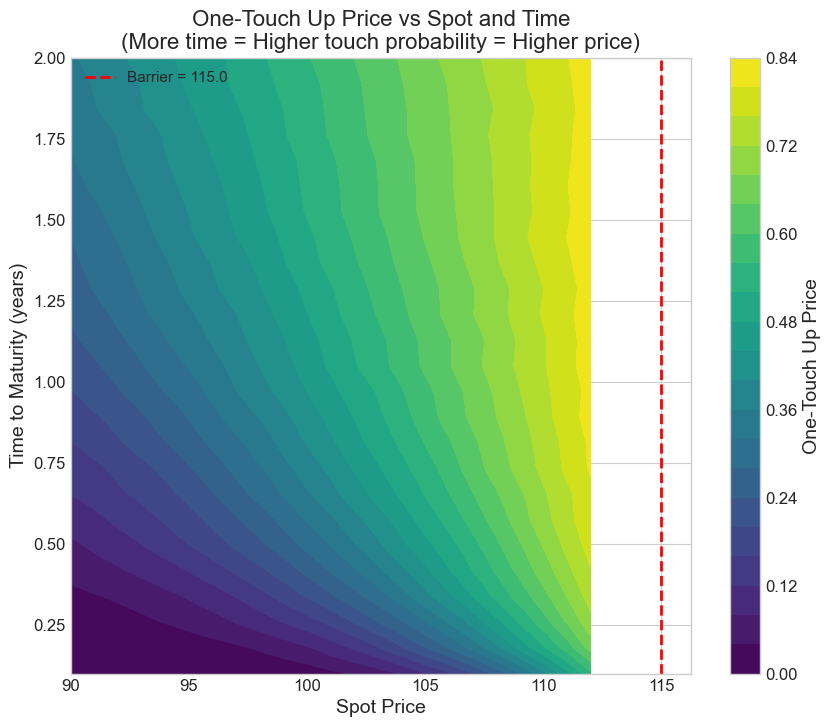

In [8]:
# Plot price vs spot and time
fig, ax = plt.subplots(figsize=(10, 8))

contour = ax.contourf(S_t_grid, T_grid, one_touch_t_prices, levels=20, cmap=cm.viridis)
plt.colorbar(contour, ax=ax, label='One-Touch Up Price')

ax.axvline(x=BASE_PARAMS['barrier_up'], color='red', linestyle='--', linewidth=2, label=f'Barrier = {BASE_PARAMS["barrier_up"]}')

ax.set_xlabel('Spot Price')
ax.set_ylabel('Time to Maturity (years)')
ax.set_title('One-Touch Up Price vs Spot and Time\n(More time = Higher touch probability = Higher price)')
ax.legend()
plt.show()

## 4. Greeks Analysis

Examining Delta, Gamma, Vega, and Theta for touch options.

In [9]:
def compute_touch_greeks_fd(S0, T, r, q, sigma, barrier, direction='up',
                            touch_style='one_touch', payout=1.0, n_paths=50000):
    """Compute Greeks using finite differences."""
    dS = 0.5
    dsigma = 0.005
    dT = 0.01
    
    # Base price
    V0, _, _, _ = touch_mc_price(S0, T, r, q, sigma, barrier, direction, touch_style, payout, n_paths=n_paths)
    
    # Delta and Gamma
    V_up, _, _, _ = touch_mc_price(S0 + dS, T, r, q, sigma, barrier, direction, touch_style, payout, n_paths=n_paths)
    V_down, _, _, _ = touch_mc_price(S0 - dS, T, r, q, sigma, barrier, direction, touch_style, payout, n_paths=n_paths)
    delta = (V_up - V_down) / (2 * dS)
    gamma = (V_up - 2*V0 + V_down) / (dS**2)
    
    # Vega
    V_sigma_up, _, _, _ = touch_mc_price(S0, T, r, q, sigma + dsigma, barrier, direction, touch_style, payout, n_paths=n_paths)
    vega = (V_sigma_up - V0) / dsigma * 0.01  # per 1% vol change
    
    # Theta
    if T > dT:
        V_T_down, _, _, _ = touch_mc_price(S0, T - dT, r, q, sigma, barrier, direction, touch_style, payout, n_paths=n_paths)
        theta = -(V0 - V_T_down) / dT / 365  # per day
    else:
        theta = 0.0
    
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta, 'price': V0}

In [10]:
# Compute Greeks across spot range
spots_for_greeks = np.linspace(90, 112, 20)
one_touch_deltas = []
one_touch_gammas = []
one_touch_vegas = []
one_touch_thetas = []

no_touch_deltas = []
no_touch_vegas = []

print("Computing Greeks...")
for S in spots_for_greeks:
    # One-Touch Greeks
    greeks_1t = compute_touch_greeks_fd(
        S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch', n_paths=30000
    )
    one_touch_deltas.append(greeks_1t['delta'])
    one_touch_gammas.append(greeks_1t['gamma'])
    one_touch_vegas.append(greeks_1t['vega'])
    one_touch_thetas.append(greeks_1t['theta'])
    
    # No-Touch Greeks
    greeks_nt = compute_touch_greeks_fd(
        S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['barrier_up'], direction='up', touch_style='no_touch', n_paths=30000
    )
    no_touch_deltas.append(greeks_nt['delta'])
    no_touch_vegas.append(greeks_nt['vega'])

print("Done!")

Computing Greeks...
Done!


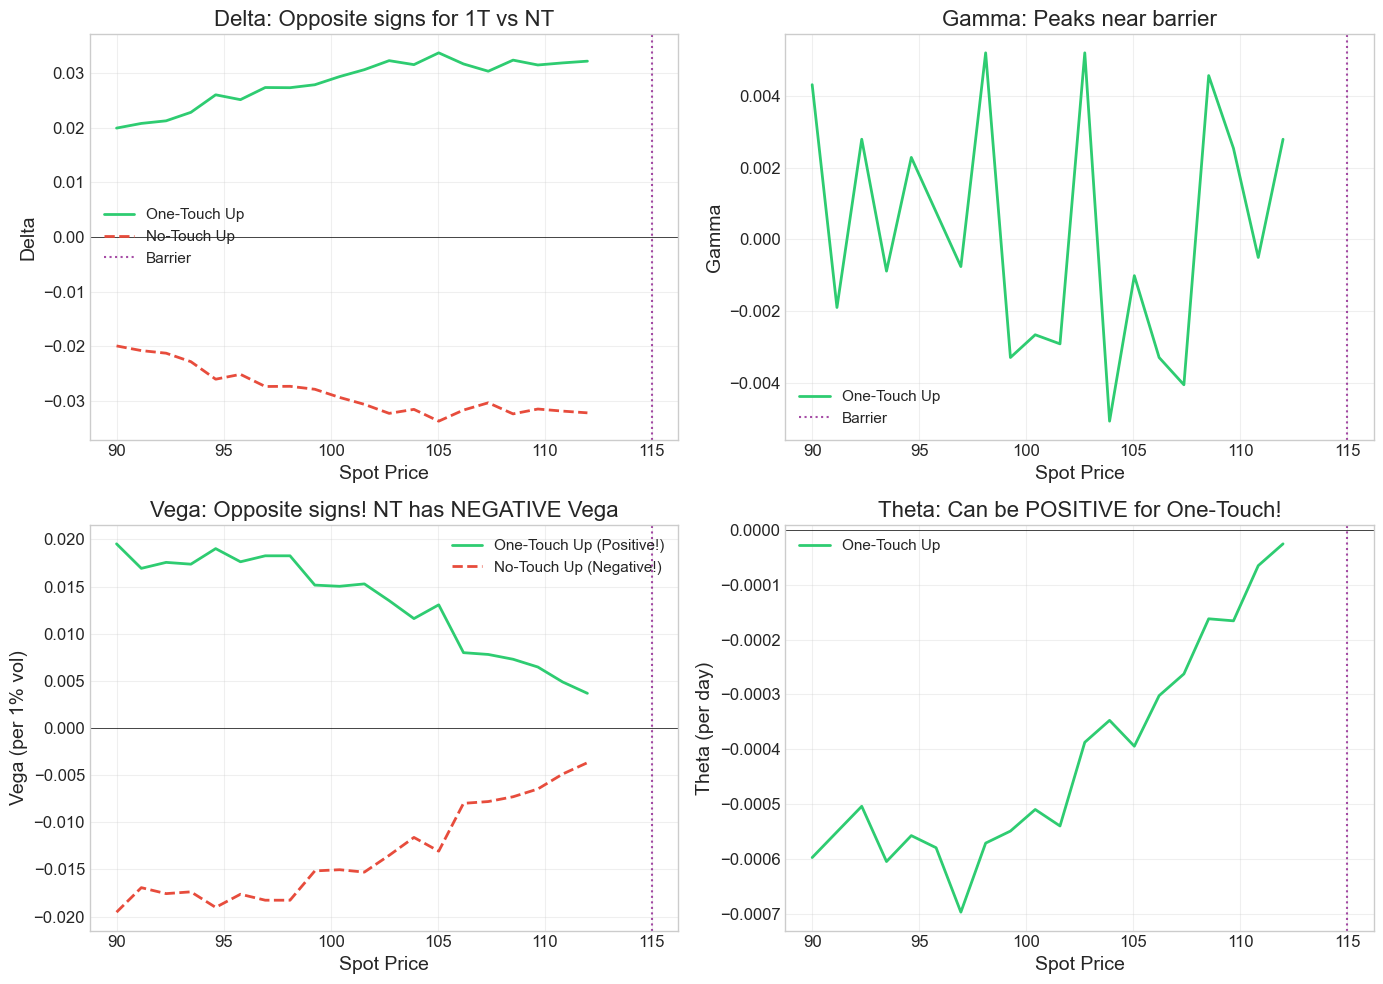

In [11]:
# Plot Greeks
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delta
ax = axes[0, 0]
ax.plot(spots_for_greeks, one_touch_deltas, color=COLORS['one_touch'], linewidth=2, label='One-Touch Up')
ax.plot(spots_for_greeks, no_touch_deltas, color=COLORS['no_touch'], linewidth=2, linestyle='--', label='No-Touch Up')
ax.axvline(x=BASE_PARAMS['barrier_up'], color='purple', linestyle=':', alpha=0.7, label='Barrier')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Delta')
ax.set_title('Delta: Opposite signs for 1T vs NT')
ax.legend()
ax.grid(True, alpha=0.3)

# Gamma
ax = axes[0, 1]
ax.plot(spots_for_greeks, one_touch_gammas, color=COLORS['one_touch'], linewidth=2, label='One-Touch Up')
ax.axvline(x=BASE_PARAMS['barrier_up'], color='purple', linestyle=':', alpha=0.7, label='Barrier')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Gamma')
ax.set_title('Gamma: Peaks near barrier')
ax.legend()
ax.grid(True, alpha=0.3)

# Vega
ax = axes[1, 0]
ax.plot(spots_for_greeks, one_touch_vegas, color=COLORS['one_touch'], linewidth=2, label='One-Touch Up (Positive!)')
ax.plot(spots_for_greeks, no_touch_vegas, color=COLORS['no_touch'], linewidth=2, linestyle='--', label='No-Touch Up (Negative!)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=BASE_PARAMS['barrier_up'], color='purple', linestyle=':', alpha=0.7)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Vega (per 1% vol)')
ax.set_title('Vega: Opposite signs! NT has NEGATIVE Vega')
ax.legend()
ax.grid(True, alpha=0.3)

# Theta
ax = axes[1, 1]
ax.plot(spots_for_greeks, one_touch_thetas, color=COLORS['one_touch'], linewidth=2, label='One-Touch Up')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=BASE_PARAMS['barrier_up'], color='purple', linestyle=':', alpha=0.7)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Theta (per day)')
ax.set_title('Theta: Can be POSITIVE for One-Touch!')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Touch-NoTouch Parity

Verifying that V_1T + V_NT = Q * e^(-rT).

In [12]:
# Verify Touch Parity: V_1T + V_NT = Q * e^(-rT)
spots_parity = np.linspace(90, 112, 15)
one_touch_prices = []
no_touch_prices = []

discounted_payout = BASE_PARAMS['payout'] * np.exp(-BASE_PARAMS['r'] * BASE_PARAMS['T'])

print("Verifying Touch-NoTouch Parity...")
for S in spots_parity:
    price_1t, _, _, _ = touch_mc_price(
        S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch', n_paths=50000
    )
    price_nt, _, _, _ = touch_mc_price(
        S, BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['barrier_up'], direction='up', touch_style='no_touch', n_paths=50000
    )
    
    one_touch_prices.append(price_1t)
    no_touch_prices.append(price_nt)

print("Done!")

Verifying Touch-NoTouch Parity...
Done!


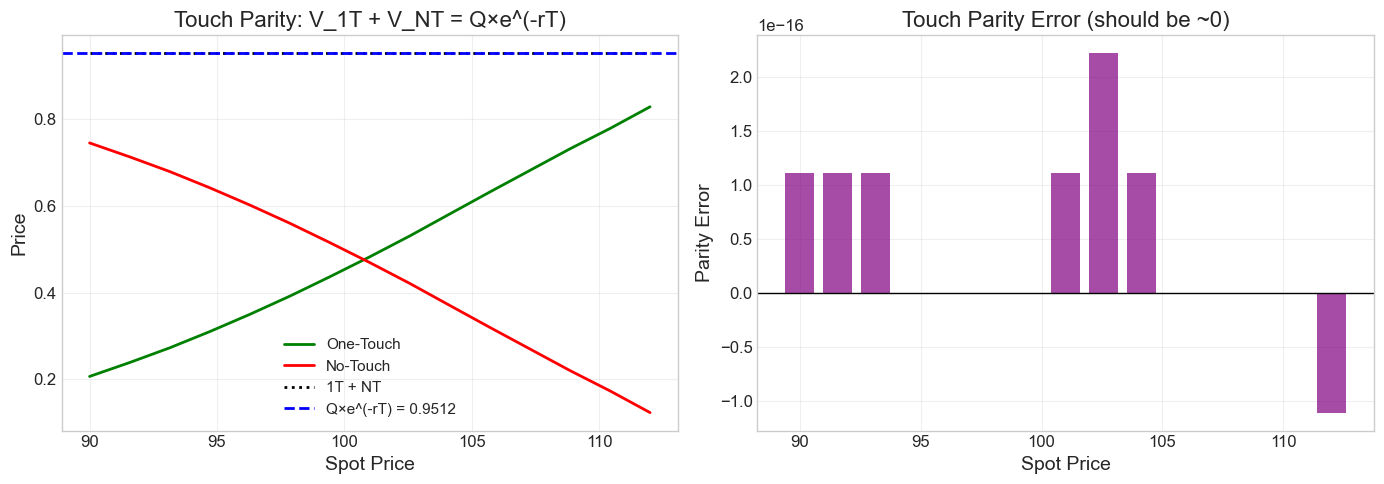


Discounted Payout Q×e^(-rT): 0.9512
Mean Absolute Parity Error: 0.000000
Max Absolute Parity Error: 0.000000


In [13]:
# Plot Touch Parity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices
ax = axes[0]
ax.plot(spots_parity, one_touch_prices, 'g-', linewidth=2, label='One-Touch')
ax.plot(spots_parity, no_touch_prices, 'r-', linewidth=2, label='No-Touch')
ax.plot(spots_parity, np.array(one_touch_prices) + np.array(no_touch_prices), 'k:', linewidth=2, label='1T + NT')
ax.axhline(y=discounted_payout, color='blue', linestyle='--', linewidth=2, label=f'Q×e^(-rT) = {discounted_payout:.4f}')
ax.set_xlabel('Spot Price')
ax.set_ylabel('Price')
ax.set_title('Touch Parity: V_1T + V_NT = Q×e^(-rT)')
ax.legend()
ax.grid(True, alpha=0.3)

# Parity Error
ax = axes[1]
parity_error = np.array(one_touch_prices) + np.array(no_touch_prices) - discounted_payout
ax.bar(spots_parity, parity_error, width=1.2, color='purple', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Parity Error')
ax.set_title('Touch Parity Error (should be ~0)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDiscounted Payout Q×e^(-rT): {discounted_payout:.4f}")
print(f"Mean Absolute Parity Error: {np.mean(np.abs(parity_error)):.6f}")
print(f"Max Absolute Parity Error: {np.max(np.abs(parity_error)):.6f}")

## 6. Touch Probability Analysis

Examining how touch probability varies with parameters.

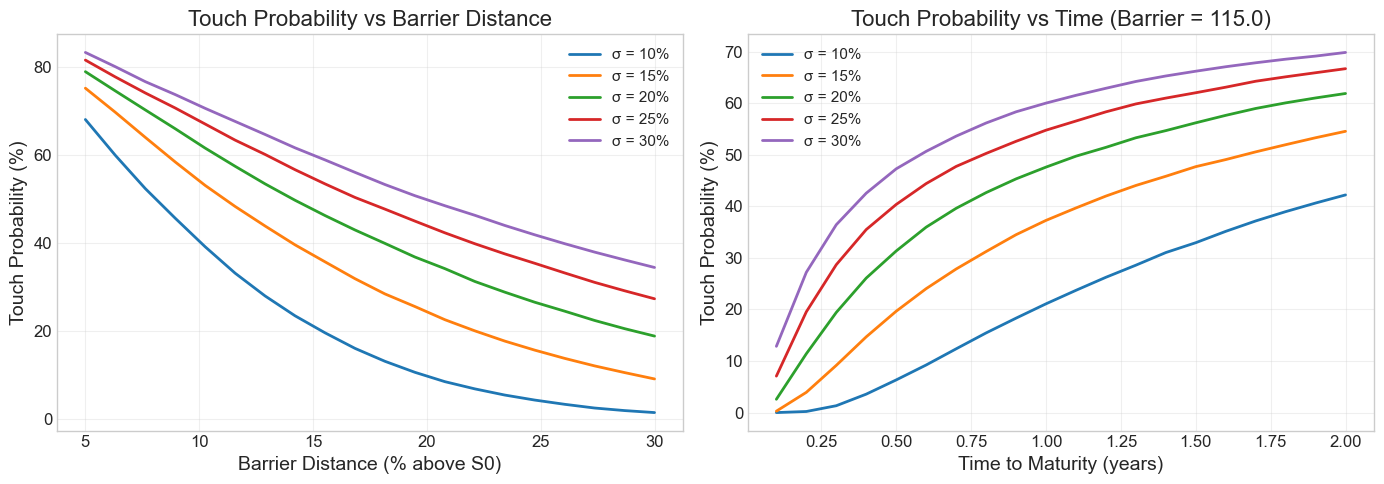

In [14]:
# Touch probability vs barrier distance for different volatilities
barrier_distances = np.linspace(5, 30, 20)  # % above S0
vols_for_analysis = [0.10, 0.15, 0.20, 0.25, 0.30]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Touch probability vs distance
ax = axes[0]
for sigma in vols_for_analysis:
    touch_probs = []
    for dist in barrier_distances:
        barrier = BASE_PARAMS['S0'] * (1 + dist/100)
        _, _, _, touched = touch_mc_price(
            BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], sigma,
            barrier, direction='up', touch_style='one_touch', n_paths=20000
        )
        touch_probs.append(np.mean(touched) * 100)
    ax.plot(barrier_distances, touch_probs, linewidth=2, label=f'σ = {sigma*100:.0f}%')

ax.set_xlabel('Barrier Distance (% above S0)')
ax.set_ylabel('Touch Probability (%)')
ax.set_title('Touch Probability vs Barrier Distance')
ax.legend()
ax.grid(True, alpha=0.3)

# Touch probability vs time
ax = axes[1]
times = np.linspace(0.1, 2.0, 20)
barrier_fixed = BASE_PARAMS['barrier_up']  # 15% above

for sigma in vols_for_analysis:
    touch_probs = []
    for T in times:
        _, _, _, touched = touch_mc_price(
            BASE_PARAMS['S0'], T, BASE_PARAMS['r'], BASE_PARAMS['q'], sigma,
            barrier_fixed, direction='up', touch_style='one_touch', n_paths=20000
        )
        touch_probs.append(np.mean(touched) * 100)
    ax.plot(times, touch_probs, linewidth=2, label=f'σ = {sigma*100:.0f}%')

ax.set_xlabel('Time to Maturity (years)')
ax.set_ylabel('Touch Probability (%)')
ax.set_title(f'Touch Probability vs Time (Barrier = {barrier_fixed})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Monte Carlo Analysis

In [15]:
# Monte Carlo convergence analysis
path_counts = [1000, 5000, 10000, 25000, 50000, 100000, 200000]
prices = []
std_errors = []

print("Running convergence analysis...")
for n in path_counts:
    price, se, _, _ = touch_mc_price(
        BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
        BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch', n_paths=n, seed=42
    )
    prices.append(price)
    std_errors.append(se)
    print(f"  n={n:7d}: price={price:.4f}, std_error={se:.4f}")

print("Done!")

Running convergence analysis...
  n=   1000: price=0.4528, std_error=0.0150
  n=   5000: price=0.4554, std_error=0.0067
  n=  10000: price=0.4519, std_error=0.0048
  n=  25000: price=0.4528, std_error=0.0030
  n=  50000: price=0.4523, std_error=0.0021
  n= 100000: price=0.4530, std_error=0.0015
  n= 200000: price=0.4548, std_error=0.0011
Done!


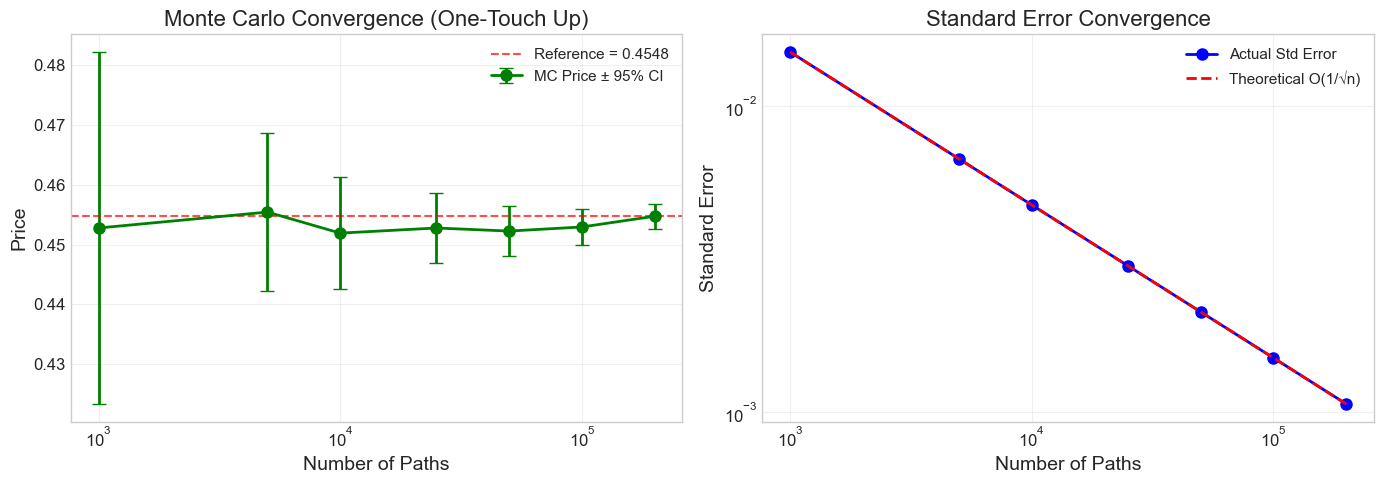

In [16]:
# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price convergence
ax = axes[0]
ax.errorbar(path_counts, prices, yerr=1.96*np.array(std_errors), 
            fmt='go-', capsize=5, linewidth=2, markersize=8, label='MC Price ± 95% CI')
ax.axhline(y=prices[-1], color='red', linestyle='--', alpha=0.7, label=f'Reference = {prices[-1]:.4f}')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Price')
ax.set_title('Monte Carlo Convergence (One-Touch Up)')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Standard error convergence
ax = axes[1]
ax.loglog(path_counts, std_errors, 'bo-', linewidth=2, markersize=8, label='Actual Std Error')
theoretical = std_errors[0] * np.sqrt(path_counts[0]) / np.sqrt(path_counts)
ax.loglog(path_counts, theoretical, 'r--', linewidth=2, label='Theoretical O(1/√n)')
ax.set_xlabel('Number of Paths')
ax.set_ylabel('Standard Error')
ax.set_title('Standard Error Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sample Paths Visualization

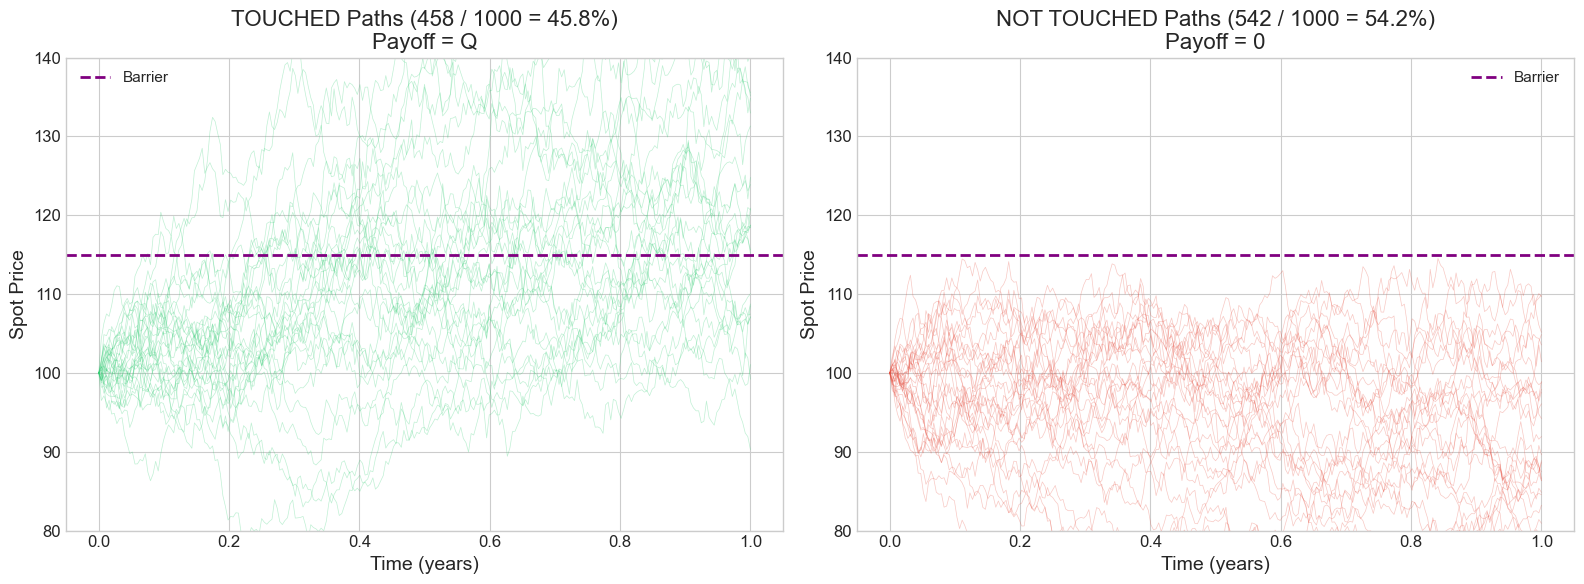

In [17]:
# Generate paths for visualization
_, _, all_paths, touched = touch_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch',
    n_paths=1000, n_steps=252, seed=123
)

# Plot sample paths
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t = np.linspace(0, 1, all_paths.shape[1])

# Touched paths
ax = axes[0]
touched_paths = all_paths[touched]
for i in range(min(30, len(touched_paths))):
    ax.plot(t, touched_paths[i], color=COLORS['touched'], alpha=0.3, linewidth=0.5)
ax.axhline(y=BASE_PARAMS['barrier_up'], color='purple', linestyle='--', linewidth=2, label='Barrier')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.set_title(f'TOUCHED Paths ({np.sum(touched)} / {len(touched)} = {100*np.mean(touched):.1f}%)\nPayoff = Q')
ax.legend()
ax.set_ylim([80, 140])

# Not touched paths
ax = axes[1]
not_touched_paths = all_paths[~touched]
for i in range(min(30, len(not_touched_paths))):
    ax.plot(t, not_touched_paths[i], color=COLORS['not_touched'], alpha=0.3, linewidth=0.5)
ax.axhline(y=BASE_PARAMS['barrier_up'], color='purple', linestyle='--', linewidth=2, label='Barrier')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spot Price')
ax.set_title(f'NOT TOUCHED Paths ({np.sum(~touched)} / {len(touched)} = {100*np.mean(~touched):.1f}%)\nPayoff = 0')
ax.legend()
ax.set_ylim([80, 140])

plt.tight_layout()
plt.show()

## Summary Statistics

In [18]:
# Final summary
print("="*60)
print("TOUCH OPTION ANALYSIS SUMMARY")
print("="*60)

# Calculate all prices
one_touch_up, _, _, touched_up = touch_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['barrier_up'], direction='up', touch_style='one_touch', n_paths=200000
)
no_touch_up, _, _, _ = touch_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['barrier_up'], direction='up', touch_style='no_touch', n_paths=200000
)
one_touch_down, _, _, touched_down = touch_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['barrier_down'], direction='down', touch_style='one_touch', n_paths=200000
)
no_touch_down, _, _, _ = touch_mc_price(
    BASE_PARAMS['S0'], BASE_PARAMS['T'], BASE_PARAMS['r'], BASE_PARAMS['q'], BASE_PARAMS['sigma'],
    BASE_PARAMS['barrier_down'], direction='down', touch_style='no_touch', n_paths=200000
)

discounted_payout = BASE_PARAMS['payout'] * np.exp(-BASE_PARAMS['r'] * BASE_PARAMS['T'])

print(f"\nParameters:")
print(f"  Spot: {BASE_PARAMS['S0']}, Payout: {BASE_PARAMS['payout']}")
print(f"  Up Barrier: {BASE_PARAMS['barrier_up']} ({100*(BASE_PARAMS['barrier_up']/BASE_PARAMS['S0']-1):.0f}% above)")
print(f"  Down Barrier: {BASE_PARAMS['barrier_down']} ({100*(1-BASE_PARAMS['barrier_down']/BASE_PARAMS['S0']):.0f}% below)")
print(f"  Volatility: {BASE_PARAMS['sigma']*100}%, Time: {BASE_PARAMS['T']} year")

print(f"\nUp Touch Options:")
print(f"  One-Touch Up:   {one_touch_up:.4f}")
print(f"  No-Touch Up:    {no_touch_up:.4f}")
print(f"  Sum:            {one_touch_up + no_touch_up:.4f} (should be {discounted_payout:.4f})")
print(f"  Touch Prob:     {100*np.mean(touched_up):.2f}%")

print(f"\nDown Touch Options:")
print(f"  One-Touch Down: {one_touch_down:.4f}")
print(f"  No-Touch Down:  {no_touch_down:.4f}")
print(f"  Sum:            {one_touch_down + no_touch_down:.4f} (should be {discounted_payout:.4f})")
print(f"  Touch Prob:     {100*np.mean(touched_down):.2f}%")

print(f"\nKey Insights:")
print(f"  - One-Touch has POSITIVE vega (higher vol = higher touch prob)")
print(f"  - No-Touch has NEGATIVE vega (higher vol = lower survival prob)")
print(f"  - One-Touch can have POSITIVE theta (more time = more chance to touch)")
print(f"  - Parity: V_1T + V_NT = Q × e^(-rT) = {discounted_payout:.4f}")

TOUCH OPTION ANALYSIS SUMMARY

Parameters:
  Spot: 100.0, Payout: 1.0
  Up Barrier: 115.0 (15% above)
  Down Barrier: 85.0 (15% below)
  Volatility: 20.0%, Time: 1.0 year

Up Touch Options:
  One-Touch Up:   0.4548
  No-Touch Up:    0.4965
  Sum:            0.9512 (should be 0.9512)
  Touch Prob:     47.81%

Down Touch Options:
  One-Touch Down: 0.3597
  No-Touch Down:  0.5915
  Sum:            0.9512 (should be 0.9512)
  Touch Prob:     37.81%

Key Insights:
  - One-Touch has POSITIVE vega (higher vol = higher touch prob)
  - No-Touch has NEGATIVE vega (higher vol = lower survival prob)
  - One-Touch can have POSITIVE theta (more time = more chance to touch)
  - Parity: V_1T + V_NT = Q × e^(-rT) = 0.9512
